In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

## Step 1: Create Simple Data

We generate data with 4 visible groups, so we can check if K-Means finds them correctly.

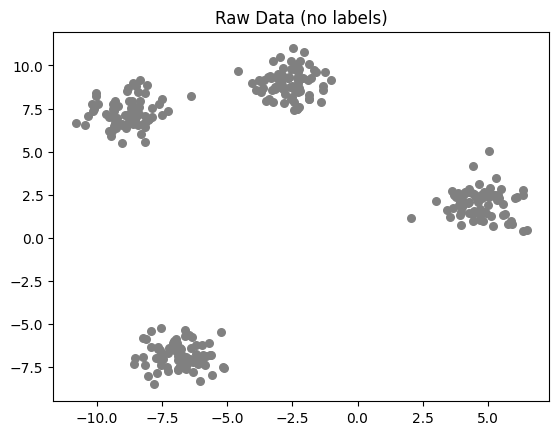

In [2]:
X, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.8, random_state=42)

plt.scatter(X[:, 0], X[:, 1], s=30, color='gray')
plt.title('Raw Data (no labels)')
plt.show()

## Step 2: Apply K-Means

In [3]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(X)

labels = kmeans.labels_
centroids = kmeans.cluster_centers_

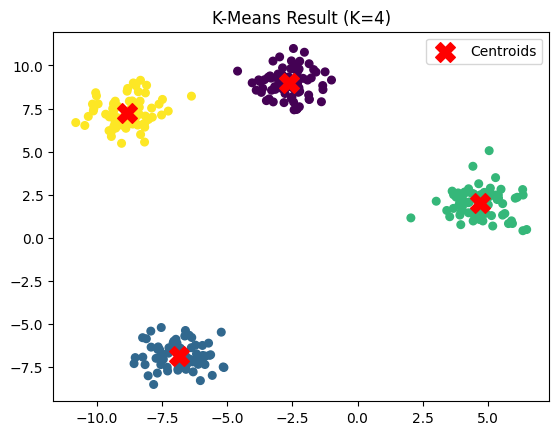

In [4]:
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=30)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, label='Centroids')
plt.title('K-Means Result (K=4)')
plt.legend()
plt.show()

Each color is a cluster K-Means found on its own. The red X marks are the centroids (cluster centers).

## Step 3: Elbow Method — Choosing K

In real problems we usually don't know K in advance. We plot inertia (how tight the clusters are) against different K values and look for the 'elbow' bend.

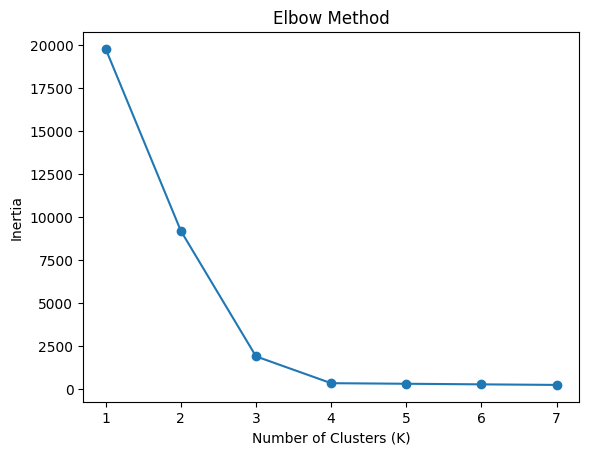

In [5]:
inertias = []
k_range = range(1, 8)

for k in k_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X)
    inertias.append(model.inertia_)

plt.plot(k_range, inertias, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

The curve bends sharply around K=4, matching the true number of groups we generated — that's the elbow.

## Summary

- K-Means groups unlabeled data by repeatedly assigning points to the nearest centroid, then updating the centroids.
- It correctly found the 4 groups in our synthetic data.
- The Elbow Method helps pick K by looking for the bend in the inertia curve.

See `KMeans_Concepts.md` for the full explanation of the concepts used here.